# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [2]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [13]:
df = pd.read_csv('cleaned_aviation_data.csv')
df.head()


,event_date,location,country,latitude,longitude,injury_severity,aircraft_damage,aircraft_category,make,model,...,total_minor_injuries,total_uninjured,weather_condition,publication_date,event_year,total_occupants,fatality_rate,serious_injury_rate,destroyed,make_model
0,1986-04-08,"MESA, AZ",United States,NaN,NaN,Non-Fatal,Substantial,Airplane,Piper Aircraft,PA-23-250,...,0,2,VMC,2011-08-03,1986,2,0.000000,0.0,0,Piper Aircraft_PA-23-250
1,1986-04-15,"HANKAMER, TX",United States,NaN,NaN,Fatal(2),Destroyed,Airplane,Grumman Aerospace,G164A,...,0,0,VMC,2013-04-08,1986,2,1.000000,0.0,1,Grumman Aerospace_G164A
2,1986-04-15,"HANKAMER, TX",United States,NaN,NaN,Fatal(2),Destroyed,Airplane,Grumman Aerospace,G164A,...,0,0,VMC,2013-04-08,1986,2,1.000000,0.0,1,Grumman Aerospace_G164A
3,1986-05-19,"MEAD, WA",United States,NaN,NaN,Fatal(2),Destroyed,Airplane,Cessna Aircraft Company,TU206F,...,1,0,VMC,2016-10-17,1986,3,0.666667,0.0,1,Cessna Aircraft Company_TU206F
4,1986-05-19,"MEAD, WA",United States,NaN,NaN,Fatal(2),Destroyed,Airplane,Cessna Aircraft Company,152,...,1,0,VMC,2016-10-17,1986,3,0.666667,0.0,1,Cessna Aircraft Company_152


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [31]:
#Assuming the size of the number of occupants in a plane dictates the size of airplane

#  Check the total records in the column total_occupants (16870 records)
print(df['total_occupants'].shape)

# Create size categories using a threshold of 20 passengers 
small_planes = df[df['total_occupants'] < 20]

large_planes = df[df['total_occupants'] >= 20]

# Check the values created for the size categories
print("\n***length of the size categories***")
print(len(small_planes))
print(len(large_planes))


(16485,)

***length of the size categories***
15993
492


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [59]:
# Create the fatal?seriously injured fraction column
df['serious_fatal_injury_fraction'] = (
    (
        df['total_fatal_injuries'] +
        df['total_serious_injuries']
    ) /
    df['total_occupants']
)

# Check NaN (385)
df['serious_fatal_injury_fraction'].isna().sum()

# Replace infinite values
df['serious_fatal_injury_fraction'] = (
    df['serious_fatal_injury_fraction']
    .replace([np.inf, -np.inf], np.nan)
)

# Drop NaNs
df = df.dropna(subset=['serious_fatal_injury_fraction'])

# Keep Small Plane Makes with a minimum sample of 20 accidents
small_make_counts = small_planes['make'].value_counts()

valid_small_makes = small_make_counts[
    small_make_counts >= 20
].index

small_planes = small_planes[
    small_planes['make'].isin(valid_small_makes)
]

# Keep Large Plane Makes with a minimum sample of 20 accidents
large_make_counts = large_planes['make'].value_counts()

valid_large_makes = large_make_counts[
    large_make_counts >= 20
].index

large_planes = large_planes[
    large_planes['make'].isin(valid_large_makes)
]

# Calculate mean serious_fatal_injury_fraction
# small aircraft with low risk
small_make_risk = (
    small_planes.groupby('make', as_index=False)[
        'serious_fatal_injury_fraction'
    ]
    .mean()
    .sort_values('serious_fatal_injury_fraction')
    .head(15)
)

# large aircraft with low risks
large_make_risk = (
    large_planes.groupby('make', as_index=False)[
        'serious_fatal_injury_fraction'
    ]
    .mean()
    .sort_values('serious_fatal_injury_fraction')
    .head(15)
)

In [60]:
# Display the small aircrafts with low risk/safest 15 small makes
small_make_risk


,make,serious_fatal_injury_fraction
22,Mcdonnell Douglas,0.127551
21,Maule,0.164806
10,Boeing,0.164869
6,Aviat Aircraft Inc,0.166667
18,Grumman Acft Eng Cor-Schweizer,0.206897
7,Ayres,0.215686
29,Stinson,0.216408
5,Aviat,0.221429
15,Diamond Aircraft Ind Inc,0.222973
9,Bellanca,0.223624


In [61]:
# Display the large aircrafts with low risk/safest 15 large makes
large_make_risk

,make,serious_fatal_injury_fraction
4,Mcdonnell Douglas,0.008176
2,Bombardier,0.052599
1,Boeing,0.101863
3,Embraer,0.102236
0,Airbus,0.164951


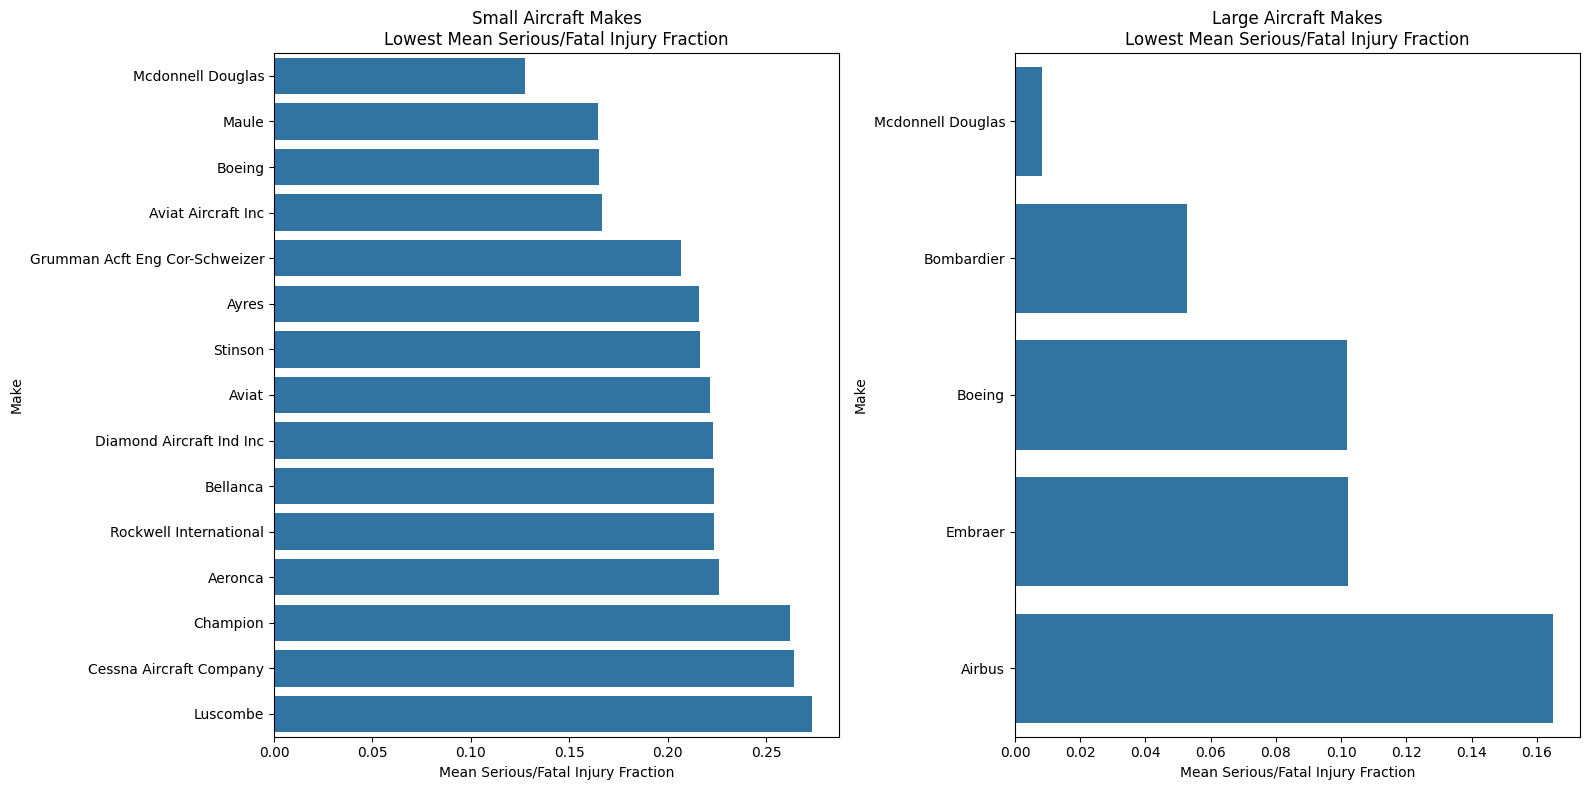

In [62]:
# fatal/seriously injured fraction for each of these subgroups side-by-side.
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 8)
)

# Small aircraft plot
sns.barplot(
    data=small_make_risk,
    x='serious_fatal_injury_fraction',
    y='make',
    ax=axes[0]
)

axes[0].set_title(
    'Small Aircraft Makes\nLowest Mean Serious/Fatal Injury Fraction'
)

axes[0].set_xlabel(
    'Mean Serious/Fatal Injury Fraction'
)

axes[0].set_ylabel('Make')

# Large aircraft plot
sns.barplot(
    data=large_make_risk,
    x='serious_fatal_injury_fraction',
    y='make',
    ax=axes[1]
)

axes[1].set_title(
    'Large Aircraft Makes\nLowest Mean Serious/Fatal Injury Fraction'
)

axes[1].set_xlabel(
    'Mean Serious/Fatal Injury Fraction'
)

axes[1].set_ylabel('Make')

plt.tight_layout()

plt.show()




**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

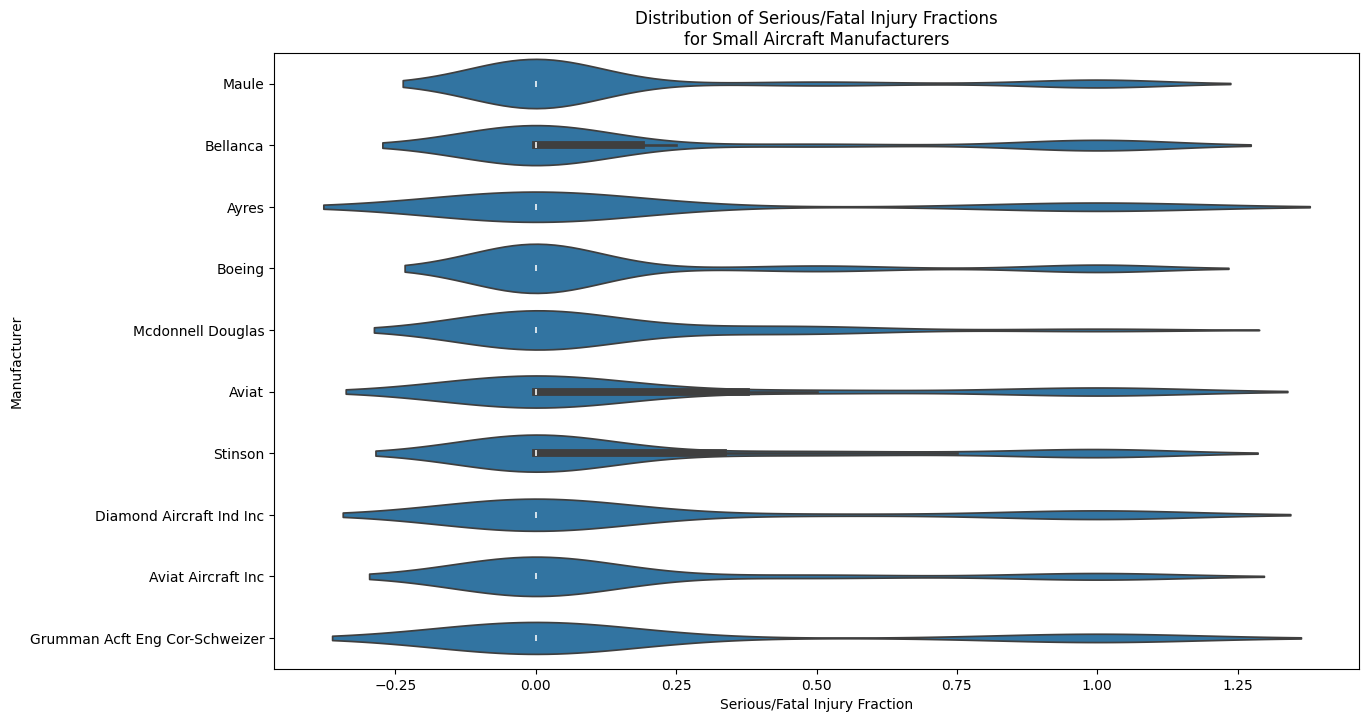

In [67]:
# 10 lowest mean serious/fatal injury rates
# Select the top 10 planes with low fatality_injury rate
top_10_small_makes = (
    small_planes
    .groupby('make', as_index=False)[
        'serious_fatal_injury_fraction'
    ]
    .mean()
    .sort_values(
        'serious_fatal_injury_fraction'
    )
    .head(10)
)

# Extract the make
top_10_make_names = top_10_small_makes['make']

# Filter the results
top_10_small_df = small_planes[
    small_planes['make'].isin(top_10_make_names)
]

# Create the violin plot
plt.figure(figsize=(14, 8))

sns.violinplot(
    data=top_10_small_df,
    x='serious_fatal_injury_fraction',
    y='make'
)

plt.title(
    'Distribution of Serious/Fatal Injury Fractions\n'
    'for Small Aircraft Manufacturers'
)

plt.xlabel(
    'Serious/Fatal Injury Fraction'
)

plt.ylabel('Manufacturer')

plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

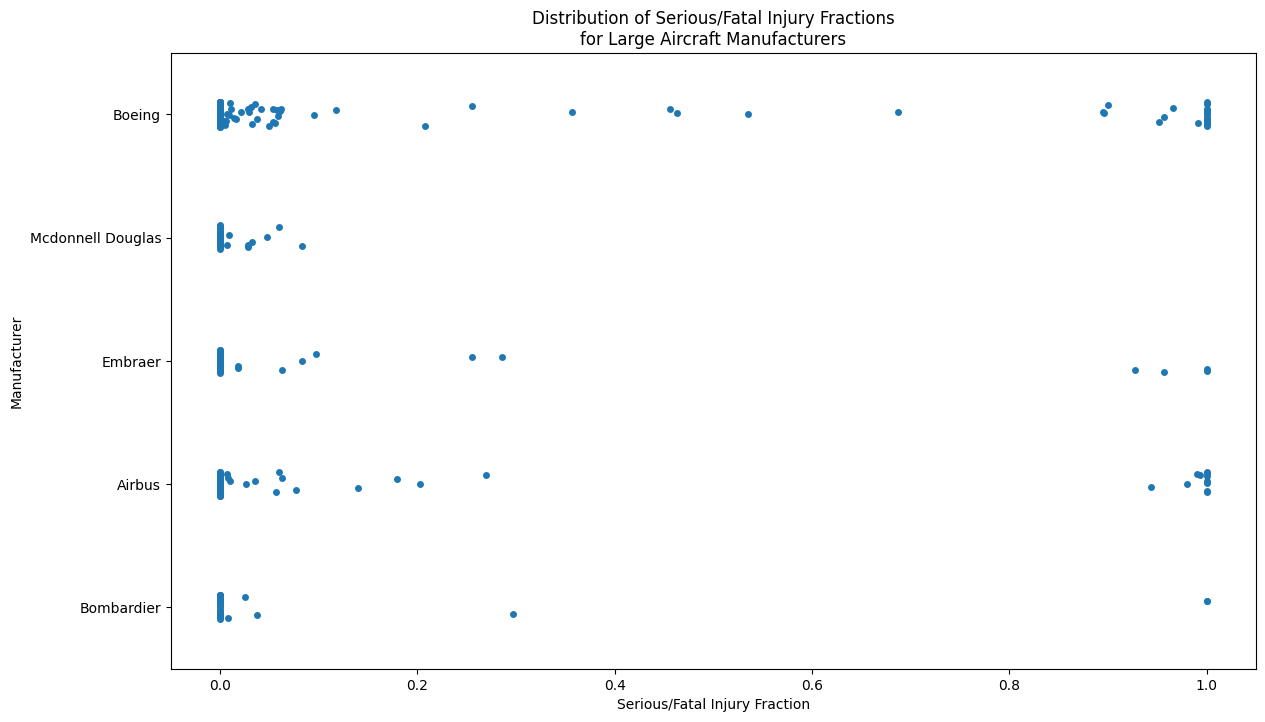

In [69]:
# 10 lowest mean serious/fatal injury rates for large aircrafts
# Select the top 10 planes with low fatality_injury rate
top_10_large_makes = (
    large_planes
    .groupby('make', as_index=False)[
        'serious_fatal_injury_fraction'
    ]
    .mean()
    .sort_values(
        'serious_fatal_injury_fraction'
    )
    .head(10)
)

# Extract the make
top_10_large_make_names = top_10_large_makes['make']

# Filter the results
top_10_large_df = large_planes[
    large_planes['make'].isin(top_10_large_make_names)
]

# Create the Strip Plot
plt.figure(figsize=(14, 8))

sns.stripplot(
    data=top_10_large_df,
    x='serious_fatal_injury_fraction',
    y='make',
    jitter=True
)

plt.title(
    'Distribution of Serious/Fatal Injury Fractions\n'
    'for Large Aircraft Manufacturers'
)

plt.xlabel(
    'Serious/Fatal Injury Fraction'
)

plt.ylabel('Manufacturer')

plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [80]:
#Recall the damaged aircraft column 'destroyed'
df['destroyed'].value_counts()

# Calculate destruction rates
# Small Manufacturers
small_make_destruction = (
    small_planes
    .groupby('make', as_index=False)[
        'destroyed'
    ]
    .mean()
    .sort_values('destroyed')
    .head(15)
)

print("\n***small_make_destruction***")
print(small_make_destruction)


# Large Manufactureres
large_make_destruction = (
    large_planes
    .groupby('make', as_index=False)[
        'destroyed'
    ]
    .mean()
    .sort_values('destroyed')
    .head(15)
)

print("\n***large_make_destruction***")
print(large_make_destruction)


***small_make_destruction***
                              make  destroyed
20                        Luscombe   0.014388
18  Grumman Acft Eng Cor-Schweizer   0.017241
29                         Stinson   0.023256
30                     Taylorcraft   0.032258
1                          Aeronca   0.035000
17                         Ercoupe   0.038462
4       American Champion Aircraft   0.039216
6               Aviat Aircraft Inc   0.040000
21                           Maule   0.041860
9                         Bellanca   0.050459
15        Diamond Aircraft Ind Inc   0.054054
12                        Champion   0.076433
11         Cessna Aircraft Company   0.095627
5                            Aviat   0.100000
14                    De Havilland   0.104167

***large_make_destruction***
                make  destroyed
2         Bombardier   0.044444
3            Embraer   0.086957
1             Boeing   0.096429
4  Mcdonnell Douglas   0.111111
0             Airbus   0.164384


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

**Findings**

The analysis compared aircraft manufacturers separately for small airplanes and larger passenger airplanes using two primary safety metrics:

* >Serious/Fatal Injury Fraction
The proportion of occupants who suffered serious or fatal injuries during accidents.

* >Aircraft Destruction Rate
The proportion of accidents resulting in total aircraft destruction.

Manufacturers with the lowest mean injury fractions and destruction rates generally demonstrated stronger safety performance and greater aircraft robustness during accidents.


**Small Aircraft Manufacturers**

Among small-aircraft manufacturers, several makes consistently exhibited:

* >low serious/fatal injury fractions,
* > and relatively low aircraft destruction rates.

The violin plots revealed that some manufacturers not only had low average injury fractions, but also relatively tight distributions centered near zero. This suggests more consistent passenger survivability outcomes across accidents.

However, some manufacturers displayed wider distributions despite low average injury fractions, indicating occasional high-severity accidents. This highlights the importance of examining full distributions rather than relying solely on averages.

Overall, manufacturers exhibiting both:

* >low average injury fractions,
* >and low destruction rates

represent the strongest safety recommendations within the small-aircraft category.


**Large Aircraft Manufacturers**

Large passenger-aircraft manufacturers generally exhibited:

* >lower injury fractions,
* >lower variability,
* >and lower destruction rates

compared to smaller aircraft.

The strip plots showed that injury outcomes for many large-aircraft manufacturers clustered heavily near zero, suggesting that many accidents resulted in relatively limited passenger injury severity.

This pattern likely reflects:

* >stricter commercial aviation safety regulations,
* >stronger structural engineering,
* >redundant aircraft systems,
* >and more rigorous operational standards.

Manufacturers with consistently low destruction rates and tightly clustered low injury fractions represent the strongest recommendations for larger passenger aircraft.Large Aircraft Manufacturers


**Recommendations**

Based on the combined analysis of:

* >serious/fatal injury fractions,
* >destruction rates,
* >and injury outcome distributions,

the recommended manufacturers are those that consistently demonstrate:

* >low average passenger injury severity,
* >low likelihood of total aircraft destruction,
* >and stable injury distributions with limited severe outliers.

Particular emphasis should be placed on manufacturers that perform well across both safety measures rather than excelling in only one metric.

Additionally, the analysis suggests that larger commercial aircraft generally provide more favorable passenger safety outcomes than smaller aircraft, likely due to stronger regulatory and engineering safeguards.


### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

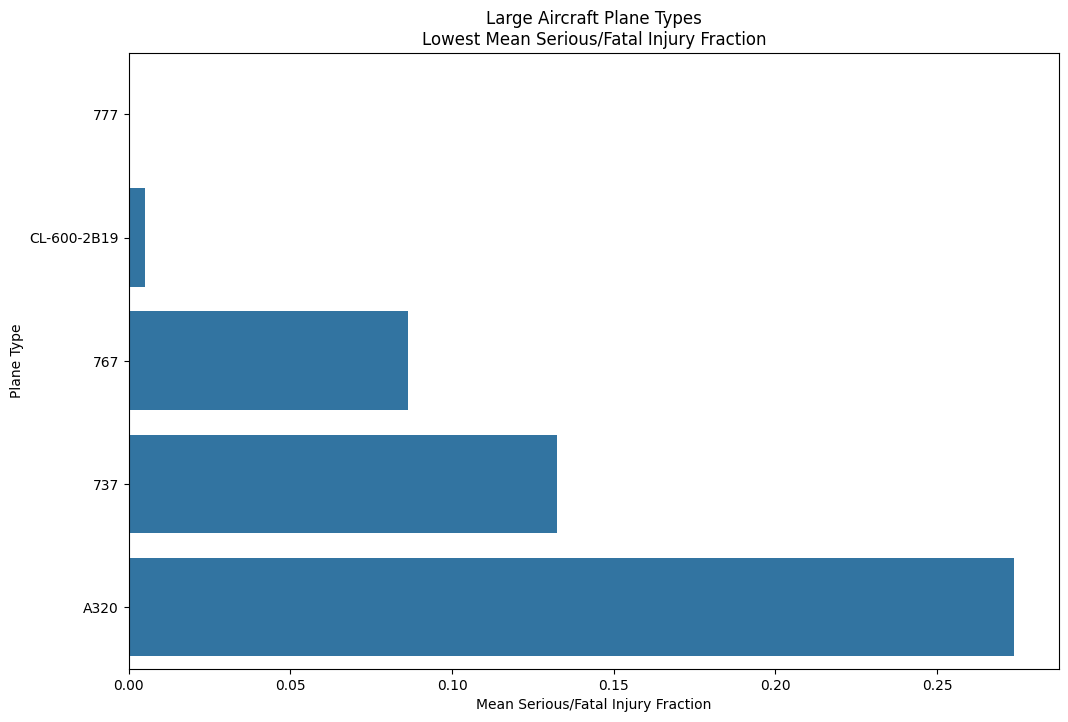

In [84]:
# Filter large plane models with at least 10 accidents
large_plane_counts = large_planes['model'].value_counts()
valid_large_models = large_plane_counts[large_plane_counts >= 10].index
large_planes_filtered = large_planes[large_planes['model'].isin(valid_large_models)]

# Calculate mean serious_fatal_injury_fraction for large plane models, sort, and take top 10 lowest
large_plane_risk = (
    large_planes_filtered.groupby('model', as_index=False)[
        'serious_fatal_injury_fraction'
    ]
    .mean()
    .sort_values('serious_fatal_injury_fraction')
    .head(10)
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=large_plane_risk,
    x='serious_fatal_injury_fraction',
    y='model'
)

plt.title(
    'Large Aircraft Plane Types\n'
    'Lowest Mean Serious/Fatal Injury Fraction'
)

plt.xlabel(
    'Mean Serious/Fatal Injury Fraction'
)

plt.ylabel('Plane Type')

plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [ ]:
plt.figure(figsize=(12, 8))

small_plane_counts = small_planes['model'].value_counts()
valid_small_models = small_plane_counts[small_plane_counts >= 10].index
small_planes_filtered = small_planes[small_planes['model'].isin(valid_small_models)]

small_plane_risk = (
    small_planes_filtered
    .groupby('model', as_index=False)['serious_fatal_injury_fraction']
    .mean()
    .sort_values('serious_fatal_injury_fraction')
    .head(10)
)

sns.barplot(
    data=small_plane_risk,
    x='serious_fatal_injury_fraction',
    y='model'
)

plt.title(
    'Small Aircraft Plane Types\n'
    'Lowest Mean Serious/Fatal Injury Fraction'
)

plt.xlabel(
    'Mean Serious/Fatal Injury Fraction'
)

plt.ylabel('Plane Type')

plt.show()

ValueError: Could not interpret value `plane_type` for `y`. An entry with this name does not appear in `data`.

<Figure size 1200x800 with 0 Axes>

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.